<a href="https://colab.research.google.com/github/LazyLatte/Fractal3D-Explorer/blob/master/Project1/ECE_232E_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install igraph

## Random walk on Erdos-Renyi networks

In [2]:
import random
def random_walk(g, start, steps):
  current = start
  for _ in range(steps):
      neighbors = g.neighbors(current)
      if not neighbors:
          break
      current = random.choice(neighbors)
  return current

In [3]:
import igraph as ig
import numpy as np
def measure_network(g, num_trials, max_steps):
  all_shortest_paths = g.shortest_paths_dijkstra()

  avg_distances = []
  var_distances = []
  end_degrees = []

  for t in range(max_steps + 1):
      distances = []

      for _ in range(num_trials):
          start = random.randint(0, num_nodes - 1)
          end = random_walk(g, start, t)

          d = all_shortest_paths[start][end]
          distances.append(d)
          if t == max_steps:
            end_degrees.append(g.degree(end))
      avg = np.mean(distances)
      var = np.var(distances)
      avg_distances.append(avg)
      var_distances.append(var)

  return avg_distances, var_distances, end_degrees, g.degree()

In [4]:
import matplotlib.pyplot as plt
def plot_avg_var(network_name, num_nodes, avg_distances, var_distances, max_steps):
  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(range(max_steps + 1), avg_distances, marker='o')
  plt.title("⟨s(t)⟩ for {} - {} nodes".format(network_name, num_nodes))
  plt.xlabel("Steps (t)")
  plt.ylabel("Average Distance ⟨s(t)⟩")

  plt.subplot(1, 2, 2)
  plt.plot(range(max_steps + 1), var_distances, marker='o', color='orange')
  plt.title("σ²(t) for {} - {} nodes".format(network_name, num_nodes))
  plt.xlabel("Steps (t)")
  plt.ylabel("Variance σ²(t)")

  plt.tight_layout()
  plt.show()

def plot_degree_distribution(network_name, num_nodes, end_degrees, graph_degrees, max_steps):
  plt.figure(figsize=(12, 5))
  plt.subplot(1, 2, 1)
  plt.hist(end_degrees, bins=range(0, max(end_degrees) + 2), edgecolor='black', align='left')
  plt.title(f"Degree Distribution of End Nodes (t={max_steps})")
  plt.xlabel("Degree")
  plt.ylabel("Probability")
  plt.grid(axis='y', linestyle='--', alpha=0.7)

  plt.subplot(1, 2, 2)
  plt.hist(graph_degrees, bins=range(min(graph_degrees), max(graph_degrees)+1), edgecolor='black')
  plt.title("Degree Distribution of the Graph")
  plt.xlabel("Degree")
  plt.ylabel("Probability")

  plt.tight_layout()
  plt.show()

<ipython-input-3-0c1e3160465e>:4: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  all_shortest_paths = g.shortest_paths_dijkstra()


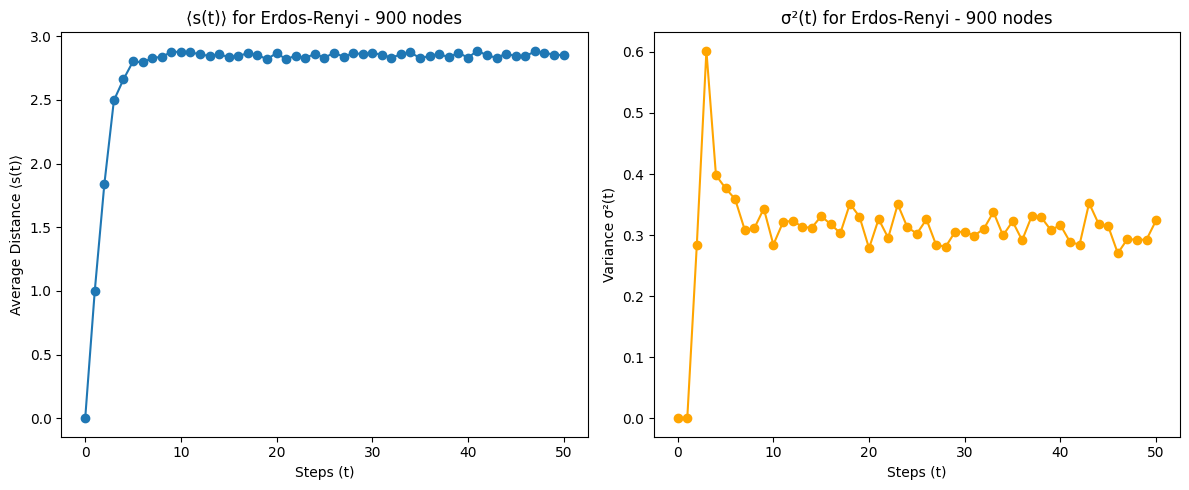

In [5]:
num_nodes = 900
edge_prob = 0.015
num_trials = 1000
max_steps = 50

g1 = ig.Graph.Erdos_Renyi(n=num_nodes, p=edge_prob, directed=False)
avg_distances, var_distances, end_degrees, graph_degrees = measure_network(g1, num_trials, max_steps)
plot_avg_var("Erdos-Renyi", num_nodes, avg_distances, var_distances, max_steps)

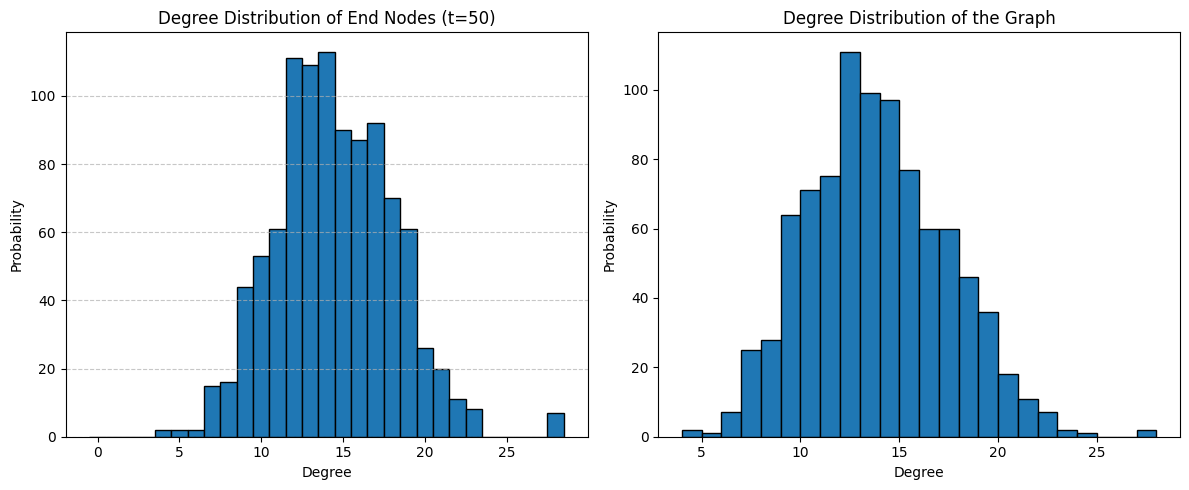

In [6]:
plot_degree_distribution("Erdos-Renyi", num_nodes, end_degrees, graph_degrees, max_steps)

<ipython-input-3-0c1e3160465e>:4: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  all_shortest_paths = g.shortest_paths_dijkstra()


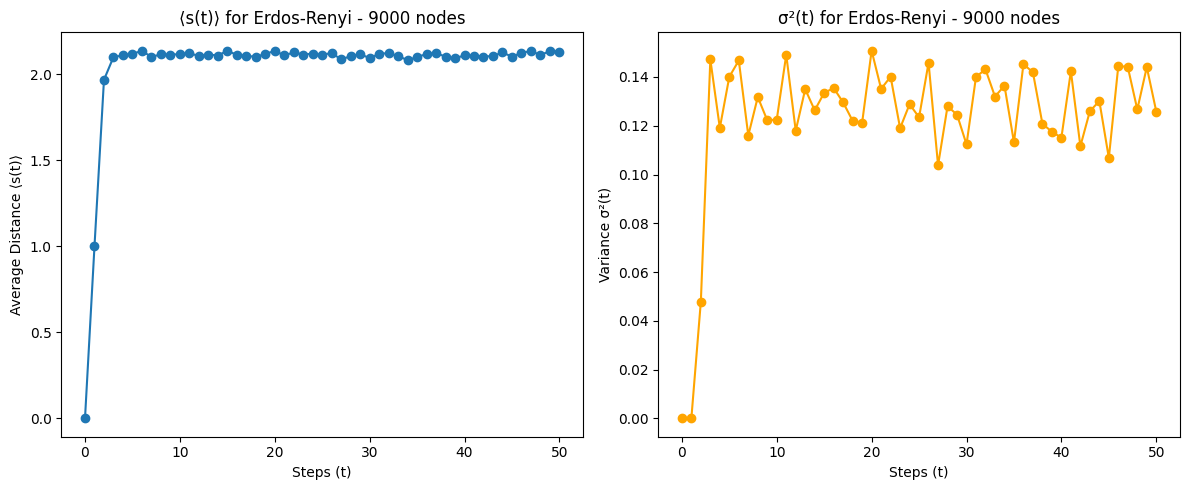

In [7]:
num_nodes = 9000
edge_prob = 0.015
num_trials = 1000
max_steps = 50

g1 = ig.Graph.Erdos_Renyi(n=num_nodes, p=edge_prob, directed=False)
avg_distances, var_distances, end_degrees, graph_degrees = measure_network(g1, num_trials, max_steps)
plot_avg_var("Erdos-Renyi", num_nodes, avg_distances, var_distances, max_steps)

## Random walk on networks with fat-tailed degree distribution

<ipython-input-3-0c1e3160465e>:4: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  all_shortest_paths = g.shortest_paths_dijkstra()


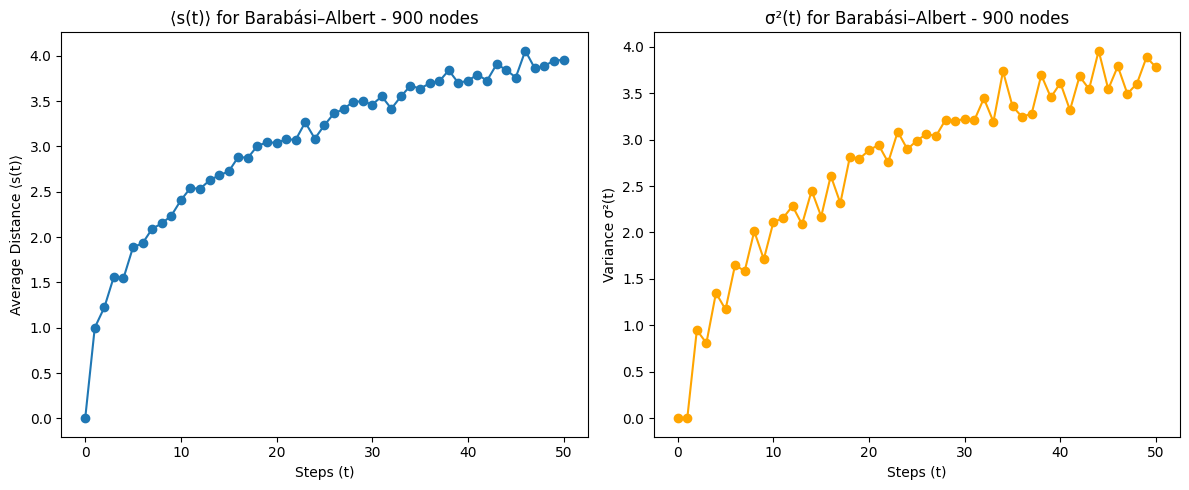

In [8]:
num_nodes = 900
num_trials = 1000
max_steps = 50

g2 = ig.Graph.Barabasi(n=num_nodes, m=1, directed=False)
avg_distances, var_distances, end_degrees, graph_degrees = measure_network(g2, num_trials, max_steps)
plot_avg_var("Barabási–Albert", num_nodes, avg_distances, var_distances, max_steps)

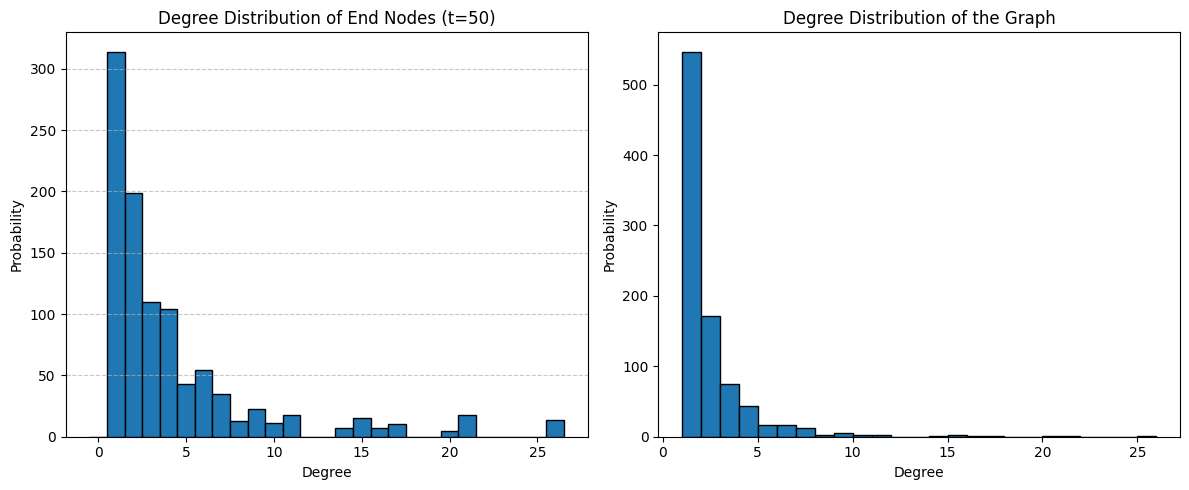

In [9]:
plot_degree_distribution("Barabási–Albert", num_nodes, end_degrees, graph_degrees, max_steps)

<ipython-input-3-0c1e3160465e>:4: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  all_shortest_paths = g.shortest_paths_dijkstra()


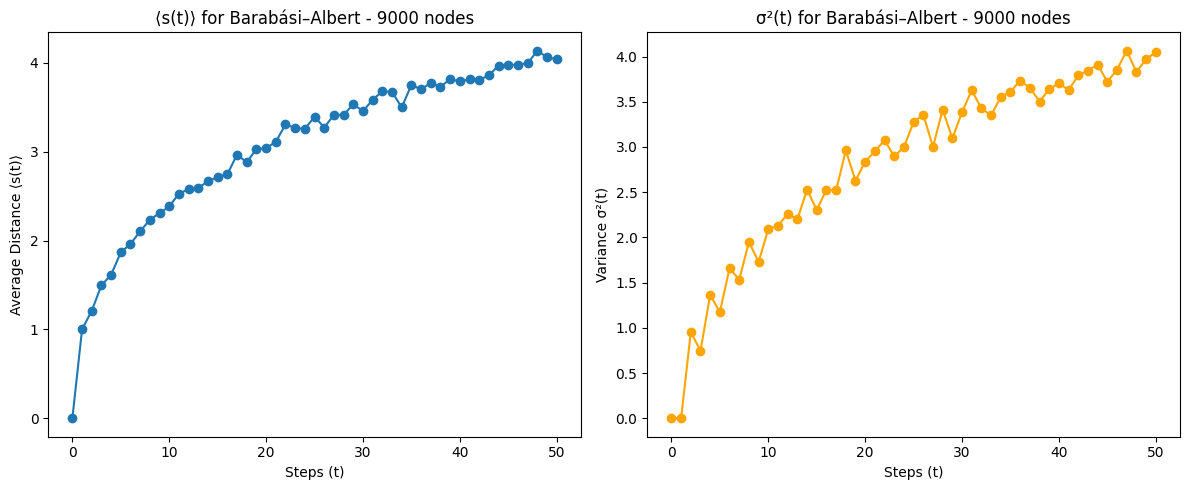

In [10]:
num_nodes = 9000
num_trials = 1000
max_steps = 50

g2 = ig.Graph.Barabasi(n=num_nodes, m=1, directed=False)
avg_distances, var_distances, end_degrees, graph_degrees = measure_network(g2, num_trials, max_steps)
plot_avg_var("Barabási–Albert", num_nodes, avg_distances, var_distances, max_steps)

## Page Rank (Still Working !!!)

In [13]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import random

num_nodes = 900
m = 4
num_steps = 100000

g1 = ig.Graph.Barabasi(n=num_nodes, m=m, directed=True)
g2 = ig.Graph.Barabasi(n=num_nodes, m=m, directed=True)

permutation = random.sample(range(num_nodes), num_nodes)
g2_permuted = g2.permute_vertices(permutation)

g1.add_edges(g2_permuted.get_edgelist())

visit_counts = [0] * num_nodes
current = random.randint(0, num_nodes - 1)

for _ in range(num_steps):
    visit_counts[current] += 1
    out_neighbors = g1.successors(current)
    assert out_neighbors # The graph should be strongly-connected
    current = random.choice(out_neighbors)

visit_prob = np.array(visit_counts) / sum(visit_counts)

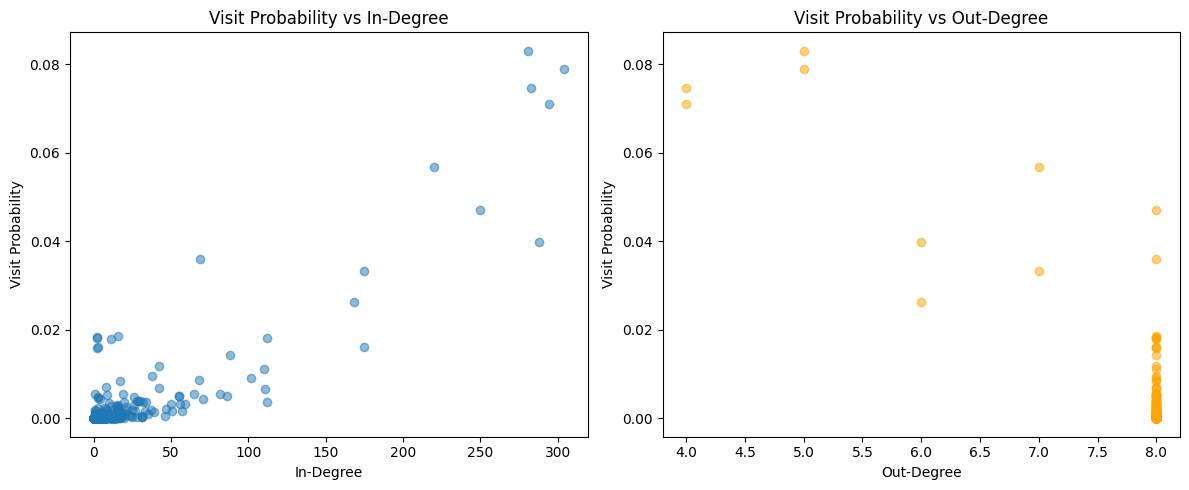

In [14]:
in_degrees = g1.indegree()
out_degrees = g1.outdegree()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(in_degrees, visit_prob, alpha=0.5)
plt.xlabel("In-Degree")
plt.ylabel("Visit Probability")
plt.title("Visit Probability vs In-Degree")

plt.subplot(1, 2, 2)
plt.scatter(out_degrees, visit_prob, alpha=0.5, color='orange')
plt.xlabel("Out-Degree")
plt.ylabel("Visit Probability")
plt.title("Visit Probability vs Out-Degree")

plt.tight_layout()
plt.show()

In [15]:
alpha = 0.2

visit_counts = [0] * num_nodes
current = random.randint(0, num_nodes - 1)

for _ in range(num_steps):
    visit_counts[current] += 1

    if random.random() < alpha:
        current = random.randint(0, num_nodes - 1)
    else:
        out_neighbors = g1.successors(current)
        assert out_neighbors # The graph should be strongly-connected
        current = random.choice(out_neighbors)

visit_prob = np.array(visit_counts) / sum(visit_counts)

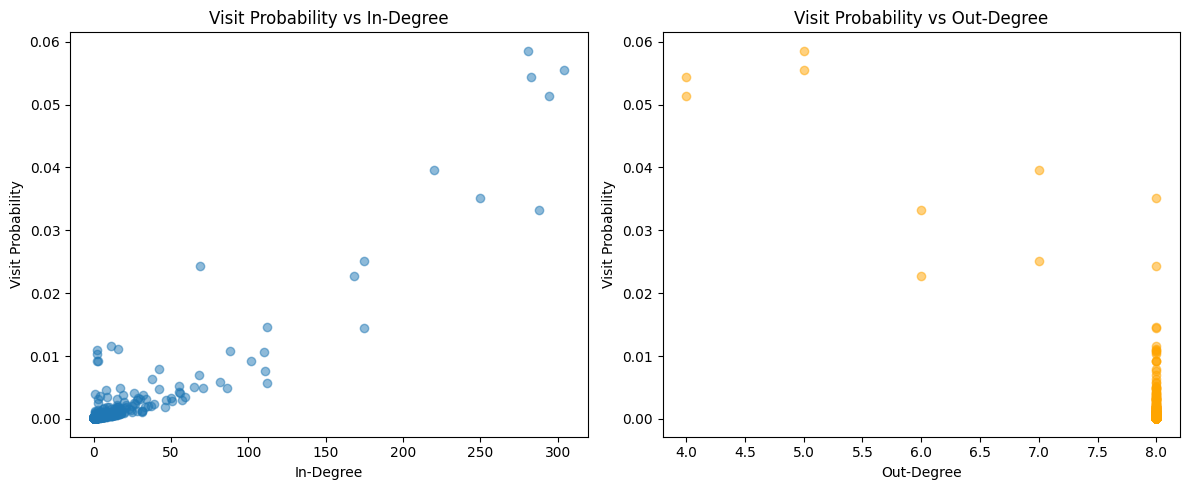

In [16]:
in_degrees = g1.indegree()
out_degrees = g1.outdegree()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(in_degrees, visit_prob, alpha=0.5)
plt.xlabel("In-Degree")
plt.ylabel("Visit Probability")
plt.title("Visit Probability vs In-Degree")

plt.subplot(1, 2, 2)
plt.scatter(out_degrees, visit_prob, alpha=0.5, color='orange')
plt.xlabel("Out-Degree")
plt.ylabel("Visit Probability")
plt.title("Visit Probability vs Out-Degree")

plt.tight_layout()
plt.show()

## Personalized PageRank (Still Working !!!)